In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# Motion of the protection front

In [2]:
# Define the variables
t = sp.symbols('t', real=True)
F, T, m_a, f = sp.symbols('F T m_a f', positive=True, real=True)
x_a = sp.Function('x_a')(t)
x_a

x_a(t)

In [3]:
# Define the force function F(t)
F_t = sp.Piecewise((F - (F/T)*t, t <= T), (0, t > T))
F_t

Piecewise((F - F*t/T, T >= t), (0, True))

In [4]:
# Define the differential equation for t < T
eq1 = sp.Eq(m_a * x_a.diff(t, t), F_t - f)
eq1

Eq(m_a*Derivative(x_a(t), (t, 2)), -f + Piecewise((F - F*t/T, T >= t), (0, True)))

In [5]:
# Solve the differential equation for t <= T
sol1 = sp.dsolve(eq1, ics={x_a.subs(t, 0): 0, x_a.diff(t).subs(t, 0): 0})

# Extract the position function for t <= T
x_a_sol1 = sol1.rhs
x_a_sol1

Piecewise((F*t**2/(2*m_a) - F*t**3/(6*T*m_a) - f*t**2/(2*m_a), T >= t), (-f*t**2/(2*m_a), True))

In [6]:
# Define the differential equation for t > T
eq2 = sp.Eq(m_a * x_a.diff(t, t), -f)
eq2

Eq(m_a*Derivative(x_a(t), (t, 2)), -f)

In [7]:
# Solve the differential equation for t >= T with continuity conditions
sol2 = sp.dsolve(eq2, ics={x_a.subs(t, T): x_a_sol1.subs(t, T), 
                           x_a.diff(t).subs(t, T): x_a_sol1.diff(t).subs(t, T)})

# Extract the position function for t >= T
x_a_sol2 = sol2.rhs
x_a_sol2

-F*T**2/(6*m_a) + F*T*t/(2*m_a) - f*t**2/(2*m_a)

In [8]:
# Combine the solutions into a piecewise function
x_a_sol = sp.Piecewise((x_a_sol1, t <= T), (x_a_sol2, t > T))

# Display the piecewise solution
x_a_sol

Piecewise((F*t**2/(2*m_a) - F*t**3/(6*T*m_a) - f*t**2/(2*m_a), T >= t), (-F*T**2/(6*m_a) + F*T*t/(2*m_a) - f*t**2/(2*m_a), True))

In [9]:
# Display the piecewise solution for velocity
v_a_sol = x_a_sol.diff(t)
v_a_sol

Piecewise((F*t/m_a - F*t**2/(2*T*m_a) - f*t/m_a, T >= t), (F*T/(2*m_a) - f*t/m_a, True))

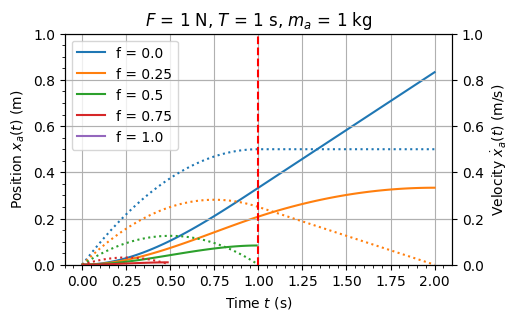

In [10]:
# Define the parameters for plotting
F_val = 1
T_val = 1
m_a_val = 1
f_vals = np.linspace(0, 1, 5)

plt.figure(figsize=(5, 3))
plt.minorticks_on()

ax = plt.gca()
ax_twin = ax.twinx()
for f_val in f_vals:
    # Substitute the parameters into the piecewise function
    x_a_sol_plot = x_a_sol.subs({F: F_val, T: T_val, m_a: m_a_val, f: f_val})
    v_a_sol_plot = v_a_sol.subs({F: F_val, T: T_val, m_a: m_a_val, f: f_val})

    # Create a numerical function for plotting
    x_a_sol_lambdified = sp.lambdify(t, x_a_sol_plot, 'numpy')
    v_a_sol_lambdified = sp.lambdify(t, v_a_sol_plot, 'numpy')

    # Generate time values for plotting
    import numpy as np
    t_vals = np.linspace(0, 2, 100)
    x_a_vals = np.where(v_a_sol_lambdified(t_vals) >= 0, x_a_sol_lambdified(t_vals), np.nan)
    v_a_vals = np.where(v_a_sol_lambdified(t_vals) >= 0, v_a_sol_lambdified(t_vals), np.nan)

    # Plot the piecewise function
    ax.plot(t_vals, x_a_vals, label=f'f = {f_val}')
    ax.set_title(f'$F$ = {F_val} N, $T$ = {T_val} s, $m_a$ = {m_a_val} kg')
    ax.set_xlabel('Time $t$ (s)')
    ax.set_ylabel('Position $x_a(t)$ (m)')
    ax.grid(True)
    
    ax_twin.plot(t_vals, v_a_vals, linestyle=':')
    ax_twin.set_ylabel('Velocity $\dot{x}_a(t)$ (m/s)')
    ax_twin.grid(True)

plt.axvline(x=T_val, color='r', linestyle='--', label='$t = T$')
ax.legend()
ax.set_ylim([0, 1])
ax_twin.set_ylim([0, 1])
plt.show()

## Non dimensionalization

In [11]:
tau, phi, xi_a = sp.symbols('tau, phi, xi_a', positive=True)

In [12]:
xi_a_sol = x_a_sol.subs({
    t: tau*T,
    f: phi*F
})*m_a/(F*(T**2))
xi_a_sol = sp.piecewise_fold(xi_a_sol).simplify().subs({T: 1})
xi_a_sol

Piecewise((tau**2*(-3*phi - tau + 3)/6, tau <= 1), (-phi*tau**2/2 + tau/2 - 1/6, True))

In [13]:
beta_a_sol = xi_a_sol.diff(tau)
beta_a_sol

Piecewise((-tau**2/6 + tau*(-3*phi - tau + 3)/3, tau <= 1), (-phi*tau + 1/2, True))

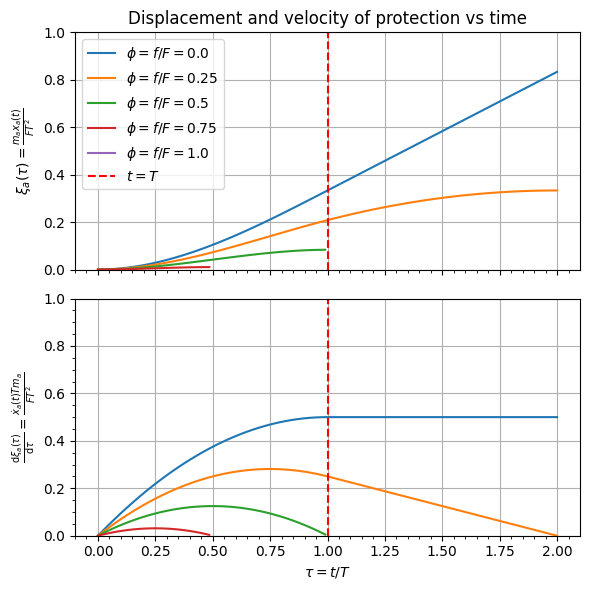

In [14]:
# Define the parameters for plotting
phi_vals = np.linspace(0, 1, 5)


fig, ax_ = plt.subplots(2, 1, figsize=(6, 6), sharex='col')

ax = ax_[0]
ax_twin = ax_[1]
for phi_val in phi_vals:
    # Substitute the parameters into the piecewise function
    xi_a_sol_plot = xi_a_sol.subs({phi: phi_val})
    beta_a_sol_plot = beta_a_sol.subs({phi: phi_val})

    # Create a numerical function for plotting
    xi_a_sol_lambdified = sp.lambdify(tau, xi_a_sol_plot, 'numpy')
    beta_a_sol_lambdified = sp.lambdify(tau, beta_a_sol_plot, 'numpy')

    # Generate time values for plotting
    import numpy as np
    tau_vals = np.linspace(0, 2, 100)
    xi_a_vals = np.where(beta_a_sol_lambdified(tau_vals) >= 0, xi_a_sol_lambdified(tau_vals), np.nan)
    beta_a_vals = np.where(beta_a_sol_lambdified(tau_vals) >= 0, beta_a_sol_lambdified(tau_vals), np.nan)

    # Plot the piecewise function
    ax.plot(tau_vals, xi_a_vals, label=f'$\phi = f/F =${phi_val}')
    ax_twin.set_xlabel(r'$\tau = t/T$')
    ax.set_ylabel(r'$\xi_a(\tau) = \frac{m_a x_a(t)}{F T^2}$')
    ax.grid(True)
    
    ax_twin.plot(tau_vals, beta_a_vals, linestyle='-')
    ax_twin.set_ylabel(r'$\frac{\mathrm{d} \xi_a(\tau)}{\mathrm{d} \tau} = \frac{\dot{x}_a(t) T m_a}{F T^2}$')
    ax_twin.grid(True)

ax.axvline(x=1, color='r', linestyle='--', label='$t = T$')
ax_twin.axvline(x=1, color='r', linestyle='--', label='$t = T$')

ax.set_title('Displacement and velocity vs time')
ax.legend()
ax.set_ylim([0, 1])
ax_twin.set_ylim([0, 1])

ax.set_title('Displacement and velocity of protection vs time')
ax.legend()
# ax.set_ylim([0, 1])
# ax_twin.set_ylim([0, 1])

plt.minorticks_on()

plt.tight_layout()
plt.savefig('protection.pdf')
plt.show()

# Calculate final time and displacement

In [15]:
try:
    from IPython.display import display, clear_output, Math, Markdown
except:
    pass


def print_solutions(solutions):
    ''' print the rendered Latex format in Jupyter cell'''
    for set_num, space in enumerate(solutions):
        latex_str = '\\text{Solution }'
        latex_str += f'{sp.latex(space)}'
        display(Math(latex_str))
        display(Markdown('---'))

## Final time

In [16]:
tau_f_sols = sp.solve(beta_a_sol, tau)
print_solutions(tau_f_sols)

combined = [(pw.args[0][0], pw.args[0][1]) for pw in tau_f_sols if pw]
combined.append((sp.oo, True))
tau_f_sol = sp.simplify(sp.Piecewise(*combined))
tau_f_sol

<IPython.core.display.Math object>

---

<IPython.core.display.Math object>

---

Piecewise((1/(2*phi), phi < 1/2), (2 - 2*phi, True))

## Final displacement

In [17]:
xi_a_sol

Piecewise((tau**2*(-3*phi - tau + 3)/6, tau <= 1), (-phi*tau**2/2 + tau/2 - 1/6, True))

In [18]:
xi_a_f_sol = sp.piecewise_fold(xi_a_sol.subs({tau: tau_f_sol})).as_expr_set_pairs(domain=sp.Interval(0, 1))
xi_a_f_sol = [(expr.simplify(), cond.as_relational(phi)) for expr, cond in xi_a_f_sol]
xi_a_f_sol = sp.Piecewise(*[(expr, cond) for expr, cond in xi_a_f_sol])
xi_a_f_sol

Piecewise((2*(1 - phi)**3/3, (phi >= 1/2) & (phi <= 1)), ((3 - 4*phi)/(24*phi), phi < 1/2))

<lambdifygenerated-21>:2: RuntimeWarning: divide by zero encountered in divide
  return select([less(phi, 1/2),True], [(1/2)/phi,2 - 2*phi], default=nan)
<lambdifygenerated-22>:2: RuntimeWarning: divide by zero encountered in divide
  return select([logical_and.reduce((greater_equal(phi, 1/2),less_equal(phi, 1))),less(phi, 1/2)], [(2/3)*(1 - phi)**3,(1/24)*(3 - 4*phi)/phi], default=nan)


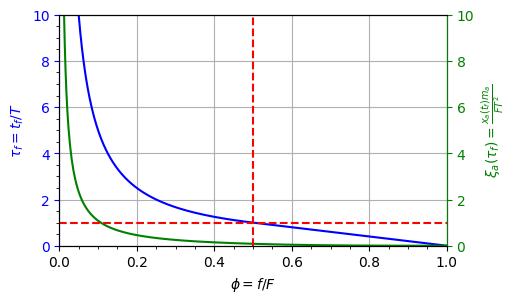

In [19]:
plt.figure(figsize=(5, 3))
plt.minorticks_on()

ax = plt.gca()
ax_twin = ax.twinx()

# Substitute the parameters into the piecewise function
tau_f_plot = tau_f_sol
xi_a_f_plot = xi_a_f_sol

# Create a numerical function for plotting
tau_f_sol_lambdified = sp.lambdify(phi, tau_f_plot, 'numpy')
xi_a_f_plot_lambdified = sp.lambdify(phi, xi_a_f_plot, 'numpy')

# Generate time values for plotting
phi_vals = np.linspace(0, 1, 500)
tau_f_vals = tau_f_sol_lambdified(phi_vals)
xi_a_f_vals = xi_a_f_plot_lambdified(phi_vals)

# Plot the piecewise function
ax.plot(phi_vals, tau_f_vals, color='blue')  # Left axis plot in blue
ax_twin.plot(phi_vals, xi_a_f_vals, color='green')  # Right axis plot in green
ax.set_xlabel(r'$\phi = f/F$')
ax.set_ylabel(r'$\tau_f = t_f/T$')
ax_twin.set_ylabel(r'$\xi_a(\tau_f) = \frac{x_a(t_f) m_a}{F T^2}$')
ax.grid(True)

# Customize axis colors
ax.spines['left'].set_color('blue')
ax.yaxis.label.set_color('blue')
ax.tick_params(axis='y', colors='blue')

ax_twin.spines['right'].set_color('green')
ax_twin.yaxis.label.set_color('green')
ax_twin.tick_params(axis='y', colors='green')

plt.axvline(x=1/2, color='r', linestyle='--')
plt.axhline(y=1, color='r', linestyle='--')
# ax.legend()
ax.set_ylim([0, 10])
ax_twin.set_ylim([0, 10])
ax.set_xlim([0, 1])
plt.show()


# Motion of the structure

In [20]:
m_s, k_s, t_f = sp.symbols('m_s k_s t_f', positive=True, real=True)
x_s = sp.Function('x_s')(t)
x_s

x_s(t)

In [21]:
# Define the differential equation for t <= t_f
eq_s1 = sp.Eq(m_s * x_s.diff(t, t), f - x_s*k_s)
eq_s1

Eq(m_s*Derivative(x_s(t), (t, 2)), f - k_s*x_s(t))

In [22]:
# Solve the differential equation for t <= t_f
sol_s1 = sp.dsolve(eq_s1, ics={x_s.subs(t, 0): 0, x_s.diff(t).subs(t, 0): 0})

# Extract the position function for t < T
x_s_sol1 = sol_s1.rhs
x_s_sol1

-f*cos(sqrt(k_s)*t/sqrt(m_s))/k_s + f/k_s

In [23]:
# Define the differential equation for t > t_f

# No cohesion
# eq_s2 = sp.Eq(m_s * x_s.diff(t, t), - x_s*k_s)

# Yes cohesion
eq_s2 = sp.Eq(m_s * x_s.diff(t, t), -f - x_s*k_s)
eq_s2

Eq(m_s*Derivative(x_s(t), (t, 2)), -f - k_s*x_s(t))

In [24]:
# Solve the differential equation for t > t_f
sol_s2 = sp.dsolve(eq_s2, ics={x_s.subs(t, t_f): x_s_sol1.subs(t, t_f), 
                               x_s.diff(t).subs(t, t_f): x_s_sol1.diff(t).subs(t, t_f)})

# Extract the position function for t < T
x_s_sol2 = sol_s2.rhs.simplify()
x_s_sol2

f*(-cos(sqrt(k_s)*t/sqrt(m_s)) + 2*cos(sqrt(k_s)*(t - t_f)/sqrt(m_s)) - 1)/k_s

In [25]:
# Combine the solutions into a piecewise function
x_s_sol = sp.piecewise_fold(sp.Piecewise((x_s_sol1, t <= t_f), (x_s_sol2, t > t_f))).simplify()

# Display the piecewise solution
x_s_sol

Piecewise((f*(1 - cos(sqrt(k_s)*t/sqrt(m_s)))/k_s, t <= t_f), (f*(-cos(sqrt(k_s)*t/sqrt(m_s)) + 2*cos(sqrt(k_s)*(t - t_f)/sqrt(m_s)) - 1)/k_s, True))

## Non dimensionalization

In [26]:
tau_s, omega_s, phi_s, tau_s_f = sp.symbols('tau_s, omega_s, phi_s, tau_s_f', positive=True, real=True)

In [27]:
xi_s_sol = x_s_sol.subs({
    t: tau_s/omega_s,
    t_f: tau_s_f/omega_s,
    m_s: k_s/(omega_s**2)
})/(f/k_s)

xi_s_sol = sp.piecewise_fold(xi_s_sol).simplify().subs({omega_s: 1})
xi_s_sol

Piecewise((1 - cos(tau_s), tau_s <= tau_s_f), (-cos(tau_s) + 2*cos(tau_s - tau_s_f) - 1, True))

In [28]:
beta_s_sol = xi_s_sol.diff(tau_s)
beta_s_sol

Piecewise((sin(tau_s), tau_s <= tau_s_f), (sin(tau_s) - 2*sin(tau_s - tau_s_f), True))

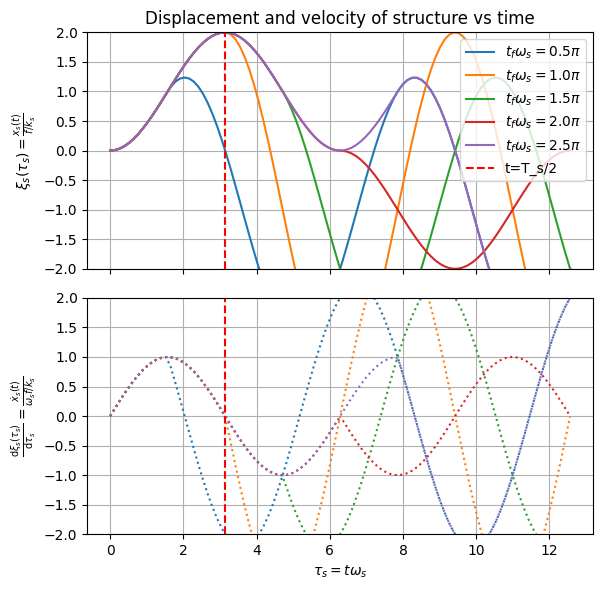

In [29]:
fig, ax_ = plt.subplots(2,1, figsize=(6, 6), sharex='col')
ax = ax_[0]
ax_twin = ax_[1]

tau_s_f_vals = np.linspace(np.pi/2, (10/4)*np.pi, 5)

for tau_s_f_val in tau_s_f_vals:
    # Substitute the parameters into the piecewise function
    xi_s_sol_plot = xi_s_sol.subs({tau_s_f: tau_s_f_val})
    beta_s_sol_plot = beta_s_sol.subs({tau_s_f: tau_s_f_val})

    # Create a numerical function for plotting
    xi_s_sol_lambdified = sp.lambdify(tau_s, xi_s_sol_plot, 'numpy')
    beta_s_sol_lambdified = sp.lambdify(tau_s, beta_s_sol_plot, 'numpy')

    # Generate time values for plotting
    tau_s_vals = np.linspace(0, 4*np.pi, 100)
    xi_s_vals = xi_s_sol_lambdified(tau_s_vals)  
    beta_s_vals = beta_s_sol_lambdified(tau_s_vals)  

    # Plot the piecewise function
    ax.plot(tau_s_vals, xi_s_vals, label=f'$t_f \omega_s ={tau_s_f_val/np.pi}\pi$')
    ax_twin.set_xlabel(r'$\tau_s = t \omega_s$')
    ax.set_ylabel(r'$\xi_s(\tau_s) = \frac{x_s(t)}{f/k_s}$')
    ax.grid(True)
    
    ax_twin.plot(tau_s_vals, beta_s_vals, linestyle=':')
    ax_twin.set_ylabel(r'$\frac{\mathrm{d}\xi_s(\tau_s)}{\mathrm{d}\tau_s} = \frac{\dot{x}_s(t)}{\omega_s f/k_s}$')
    ax_twin.grid(True)


ax.set_title('Displacement and velocity of structure vs time')
ax.axvline(x=np.pi, linestyle='--', color='red', label='t=T_s/2')
ax_twin.axvline(x=np.pi, linestyle='--', color='red')
ax.legend()
ax.set_ylim([-2, 2])
ax_twin.set_ylim([-2, 2])
plt.tight_layout()
plt.savefig('structure.pdf')
plt.show()

## Time of max displacement in the structure

In [30]:
n = sp.symbols('n', integer=True)

# velocity during maximum structure displacement
beta_a_sol_after_t_f_eq = sp.Eq(tau_s, sp.pi -(tau_s - tau_s_f) + n*2*sp.pi)
beta_a_sol_after_t_f_eq

Eq(tau_s, 2*pi*n - tau_s + tau_s_f + pi)

In [31]:
# Definir la función por tramos
piecewise_func = xi_s_sol

# Encontrar los puntos críticos resolviendo la derivada igual a cero
critical_points = sp.solve(beta_a_sol_after_t_f_eq, tau_s)
critical_points[0]


pi*n + tau_s_f/2 + pi/2

In [32]:
# Evaluar la función en los puntos críticos y en los extremos del dominio
max_values = []
for point in critical_points:
    if point.is_real:
        max_values.append(piecewise_func.subs({tau_s: point}).subs(n, 0))

# Evaluar en los extremos del dominio
max_values.append(piecewise_func.subs(tau_s, tau_s_f).simplify())
max_values.append(piecewise_func.subs(tau_s, sp.pi).simplify())

# Encontrar el máximo valor
xi_s_max = sp.simplify(sp.Max(*max_values))

xi_s_max

Max(1 - cos(tau_s_f), Piecewise((2, tau_s_f >= pi), (-2*cos(tau_s_f), True)), Piecewise((sin(tau_s_f/2) + 1, tau_s_f >= pi), (3*sin(tau_s_f/2) - 1, True)))

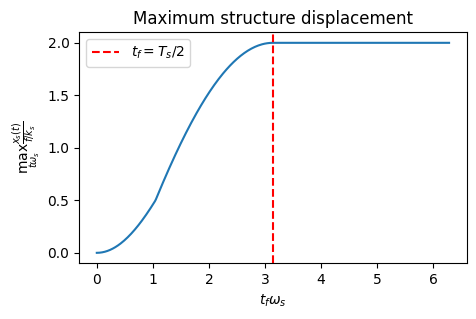

In [33]:
# Convertir la expresión de SymPy a una función de Python
xi_s_max_lambdified = sp.lambdify(tau_s_f, xi_s_max, 'numpy')

# Crear un rango de valores para tau_s
tau_s_f_values = np.linspace(0, 2*np.pi, 400)

# Evaluar la expresión para cada valor de tau_s
# xi_s_max_values = np.array([xi_s_max_lambdified(tau_s_f_value) for tau_s_f_value in tau_s_f_values])
xi_s_max_values = xi_s_max_lambdified(tau_s_f_values)


# Graficar la expresión
plt.figure(figsize=(5, 3))
plt.plot(tau_s_f_values, xi_s_max_values)
plt.xlabel(r'$t_f \omega_s$')
plt.ylabel(r'$\max_{t\omega_s} \frac{x_s(t)} {f/k_s} $')
plt.title('Maximum structure displacement')
plt.axvline(x=np.pi, color='red', linestyle='--', label='$t_f = T_s/2$')
plt.legend()
# plt.grid(True)
plt.show()

# Optimization of $f$

## Solve $\xi_{af}$ for $\phi$

In [34]:
xi_a_f = sp.symbols('xi_a_f', real=True, positive=True)

In [35]:
xi_a_eq = sp.Eq(xi_a_f, xi_a_f_sol)
xi_a_eq

Eq(xi_a_f, Piecewise((2*(1 - phi)**3/3, (phi >= 1/2) & (phi <= 1)), ((3 - 4*phi)/(24*phi), phi < 1/2)))

In [36]:
phi_sols = sp.solve(xi_a_eq, phi)



In [37]:
print_solutions(phi_sols)

combined = []
for pw in phi_sols:
    if pw:
        expr, cond = pw.args[0]
        simplified_expr = expr.simplify()
        if isinstance(cond, sp.And):
            collected_cond = sp.And(*[c.collect(xi_a_f) if hasattr(c, 'collect') else c for c in cond.args])
        else:
            collected_cond = cond.collect(xi_a_f) if hasattr(cond, 'collect') else cond
        combined.append((simplified_expr, collected_cond))
# combined.append((0, True))
phi_sol = sp.Piecewise(*combined).simplify()
phi_sol

<IPython.core.display.Math object>

---

<IPython.core.display.Math object>

---

Piecewise((3/(4*(6*xi_a_f + 1)), 1/(6*xi_a_f + 1) < 2/3), (-2**(2/3)*3**(1/3)*xi_a_f**(1/3)/2 + 1, 2**(2/3)*3**(1/3)*xi_a_f**(1/3) <= 1))

In [38]:
phi_sol_set_pairs = phi_sol.as_expr_set_pairs()
phi_sol = sp.Piecewise(*[(expr.simplify(), cond) for expr, cond in 
                            [(expr.simplify(), cond.as_relational(xi_a_f)) for expr, cond in phi_sol_set_pairs]])
phi_sol

Piecewise((3/(4*(6*xi_a_f + 1)), xi_a_f > 1/12), (-2**(2/3)*3**(1/3)*xi_a_f**(1/3)/2 + 1, True))

## $\tau_f$ as a function of $\xi_{af}$ 

In [39]:
tau_f_sol

Piecewise((1/(2*phi), phi < 1/2), (2 - 2*phi, True))

In [40]:
tau_f = sp.piecewise_exclusive(sp.piecewise_fold(tau_f_sol.subs({phi: phi_sol}))).simplify()
tau_f = sp.Piecewise(*[(expr.simplify(), cond) for expr, cond in 
                            [(expr.simplify(), cond.as_relational(xi_a_f)) for expr, cond in tau_f.as_expr_set_pairs()]])
tau_f

Piecewise((4*xi_a_f + 2/3, xi_a_f > 1/12), (2**(2/3)*3**(1/3)*xi_a_f**(1/3), True))

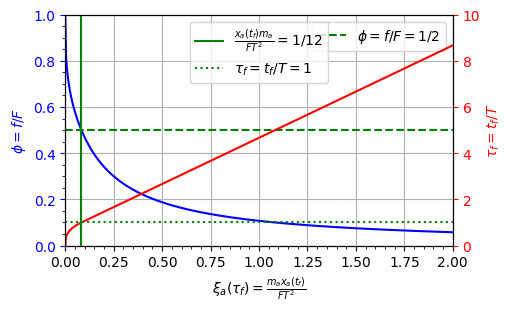

In [41]:
plt.figure(figsize=(5, 3))
plt.minorticks_on()

ax = plt.gca()
ax_twin = plt.twinx(ax)

# Substitute the parameters into the piecewise function
phi_sol_plot = phi_sol
tau_f_plot = tau_f

# Create a numerical function for plotting
phi_sol_lambdified = sp.lambdify(xi_a_f, phi_sol_plot, 'numpy')
tau_f_lambdified = sp.lambdify(xi_a_f, tau_f_plot, 'numpy')

# Generate time values for plotting
xi_a_f_vals = np.linspace(0, 2, 500)
phi_vals = phi_sol_lambdified(xi_a_f_vals)
tau_f_vals = tau_f_lambdified(xi_a_f_vals)

# Plot the piecewise function
ax.plot(xi_a_f_vals, phi_vals, color='blue')  # Left axis plot in blue
ax_twin.plot(xi_a_f_vals, tau_f_vals, color='red')  # Right axis plot in red
ax.set_ylabel(r'$\phi = f/F$')
ax_twin.set_ylabel(r'$\tau_f = t_f/T$')
ax.set_xlabel(r'$\xi_a(\tau_f) = \frac{m_a x_{a}(t_f)}{F T^2}$')
ax.grid(True)

ax.set_xlim([0, 2])
ax.set_ylim([0, 1])
ax_twin.set_ylim([0, 10])

# Guide lines
ax_twin.axvline(x=1/12, color='g', linestyle='-', label=r'$\frac{x_{a}(t_f) m_a}{F T^2}=1/12$')
ax.axhline(y=1/2, color='g', linestyle='--', label=r'$\phi = f / F = 1/2$')
ax_twin.axhline(y=1, color='g', linestyle=':', label=r'$\tau_f = t_f / T = 1$')

ax.legend()
ax_twin.legend()

# Customize axis colors
ax.yaxis.label.set_color('blue')
ax.tick_params(axis='y', colors='blue')
ax_twin.yaxis.label.set_color('red')
ax_twin.tick_params(axis='y', colors='red')
plt.show()


## Optimum $f$ assuming $\xi_s(t)=0$

In [42]:
from typing import Tuple


def f_t_f_opt(F: float, T: float, m_a: float, x_a_f: float) -> Tuple[float, float]:
    xi_a_f = x_a_f*m_a/(F * (T**2))
    f = F * phi_sol_lambdified(xi_a_f)
    t_f = T*tau_f_lambdified(xi_a_f)
    return (f, t_f)

## Optimum $f$ assuming $$t_f = \arg\max_{t} (x_a(t) - x_s(t)): \dot{x}_a(t_f) = 0$$

In [43]:
def x_s_f(m_s: float, k_s: float, t_f, f) -> float:
    omega_s = np.sqrt(k_s/m_s)
    tau_s_f = t_f * omega_s
    xi_s_f = xi_s_sol_lambdified(tau_s_f)
    return xi_s_f*(f/k_s)


def x_s_max(m_s: float, k_s: float, t_f, f) -> float:
    omega_s = np.sqrt(k_s/m_s)
    tau_s_f = t_f * omega_s
    xi_s_max = xi_s_max_lambdified(tau_s_f)
    return xi_s_max*(f/k_s)

## Iterative approximation of optimum $f$

Loading: F_=324576.000000 N, T_=0.005000 s
Baseline: x_s_max(m_s_, k_s_, T_/2, F_)=0.022219 m
x_s_f_=0.000000, x_a_f_=0.027500, (x_a_f_-x_s_f_)=0.027500, t_f_= inf, f_=0.000000, x_s_max_= nan
x_s_f_=0.011734, x_a_f_=0.039234, (x_a_f_-x_s_f_)=0.027500, t_f_=0.005367, f_=151197.500138, x_s_max_=0.014506
x_s_f_=0.006317, x_a_f_=0.033817, (x_a_f_-x_s_f_)=0.027500, t_f_=0.006234, f_=130155.290221, x_s_max_=0.012487
x_s_f_=0.008732, x_a_f_=0.036232, (x_a_f_-x_s_f_)=0.027500, t_f_=0.005834, f_=139091.536058, x_s_max_=0.013345
x_s_f_=0.007628, x_a_f_=0.035128, (x_a_f_-x_s_f_)=0.027500, t_f_=0.006012, f_=134961.144462, x_s_max_=0.012948
x_s_f_=0.008128, x_a_f_=0.035628, (x_a_f_-x_s_f_)=0.027500, t_f_=0.005931, f_=136818.529608, x_s_max_=0.013127
x_s_f_=0.007900, x_a_f_=0.035400, (x_a_f_-x_s_f_)=0.027500, t_f_=0.005968, f_=135970.982473, x_s_max_=0.013045
x_s_f_=0.008004, x_a_f_=0.035504, (x_a_f_-x_s_f_)=0.027500, t_f_=0.005951, f_=136355.336813, x_s_max_=0.013082
x_s_f_=0.007957, x_a_f_=0.03545

<lambdifygenerated-33>:2: RuntimeWarning: invalid value encountered in cos
  return amax((1 - cos(tau_s_f),select([greater_equal(tau_s_f, pi),True], [2,-2*cos(tau_s_f)], default=nan),select([greater_equal(tau_s_f, pi),True], [sin((1/2)*tau_s_f) + 1,3*sin((1/2)*tau_s_f) - 1], default=nan)), axis=0)
<lambdifygenerated-33>:2: RuntimeWarning: invalid value encountered in sin
  return amax((1 - cos(tau_s_f),select([greater_equal(tau_s_f, pi),True], [2,-2*cos(tau_s_f)], default=nan),select([greater_equal(tau_s_f, pi),True], [sin((1/2)*tau_s_f) + 1,3*sin((1/2)*tau_s_f) - 1], default=nan)), axis=0)


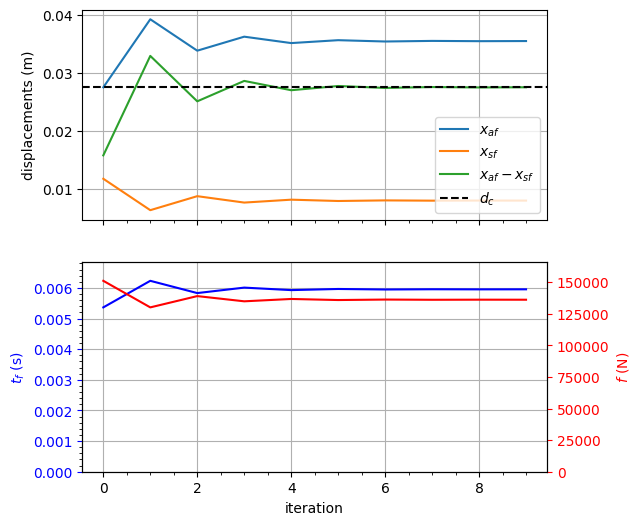

In [44]:
n_iter = 10

k_s_ = (57.6 * 2 / np.pi) * (2 * np.pi * 120) ** 2
m_s_ = 57.6 * 2 / np.pi

load_factor = 2.0
brick_area = 0.23*0.24
F_ = 10e6*.294*brick_area * load_factor

T_ = 5e-3

m_a_ = 30

d_c_ = 0.05*.55


# Assuming the loading is a triangle, duration must be halved because x_s_max asumes a rectangular pulse
print(f'Loading: {F_=:4f} N, {T_=:4f} s')
print(f'Baseline: {x_s_max(m_s_, k_s_, T_/2, F_)=:4f} m')


def iter_opt(n_iter, k_s_, m_s_, F_, T_, m_a_, d_c_, x_s_f_: float = 0, t_f_: float = np.inf, f_: float = 0, verbose: bool = True):
    x_s_f_list, x_a_f_list, t_f_list, f_list = [], [], [], []
    for i in range(n_iter):
        x_a_f_ = d_c_ + x_s_f_
        x_s_max_ = x_s_max(m_s_, k_s_, t_f_, f_) if t_f_ > T_ else np.nan
        if verbose:
            print(f'{x_s_f_=:4f}, {x_a_f_=:4f}, {(x_a_f_-x_s_f_)=:4f}, {t_f_=:4f}, {f_=:4f}, {x_s_max_=:4f}')
        f_, t_f_ = f_t_f_opt(F=F_, T=T_, m_a=m_a_, x_a_f=x_a_f_)
        x_s_f_ = x_s_f(m_s=m_s_, k_s=k_s_, t_f=t_f_, f=f_)
        x_s_f_list.append(x_s_f_)
        x_a_f_list.append(x_a_f_)
        t_f_list.append(t_f_)
        f_list.append(f_)
    return x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_

x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, m_s_, F_, T_, m_a_, d_c_)

fig, ax = plt.subplots(2, 1, figsize=(6,6), sharex='col')
plt.minorticks_on()

ax[0].plot(x_a_f_list, label=r'$x_{af}$')
ax[0].plot(x_s_f_list, label=r'$x_{sf}$')
ax[0].plot(np.array(x_a_f_list) - np.array(x_s_f_list), label=r'$x_{af} - x_{sf}$')
ax[0].axhline(y=d_c_, color='black', linestyle='--', label=r'$d_c$')
ax[0].set_ylabel('displacements (m)')
ax[0].legend()
ax[0].grid()

ax[1].plot(t_f_list, label=r'$t_f$', color='b')
ax[1].set_ylabel(r'$t_f$ (s)')
ax[1].yaxis.label.set_color('blue')
ax[1].tick_params(axis='y', colors='blue')
ax[1].set_ylim([0, 1.1*max(t_f_list)])
ax[1].grid()

ax_twin = plt.twinx(ax[1])
ax_twin.plot(f_list, label=r'$f$', color='r')
ax_twin.set_ylabel(r'$f$ (N)')
ax_twin.yaxis.label.set_color('red')
ax_twin.tick_params(axis='y', colors='red')
ax_twin.set_ylim([0, 1.1*max(f_list)])
ax[1].set_xlabel('iteration')
plt.show()

In [49]:
import pickle


# Brute force optimum results for comparison
with open('optimum_brute_force.pkl', 'rb') as file:
    (optimum_parameters, optimum_performance) = pickle.load(file=file)

# Analytically optimized results for comparison
with open('optimized.pkl', 'rb') as file:
    (optimized_parameters, optimized_performance) = pickle.load(file=file)

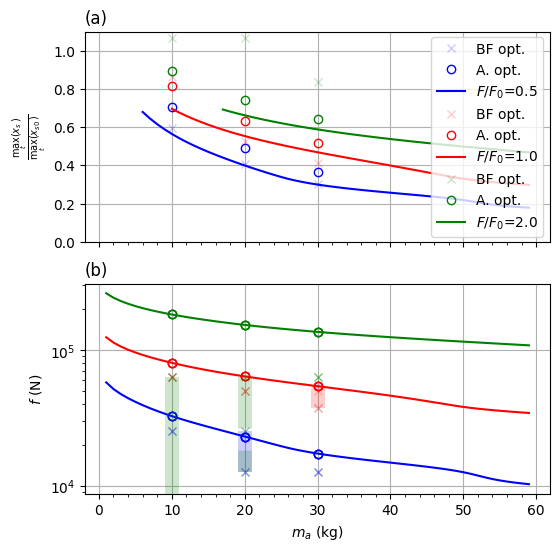

In [89]:
n_iter = 10

verbose = False
k_s_ = (57.6 * 2 / np.pi) * (2 * np.pi * 120) ** 2
m_s_ = 57.6 * 2 / np.pi

fig, ax = plt.subplots(2, 1, figsize=(6,6), sharex='col')
plt.minorticks_on()

load_factor_values = [0.5, 1.0, 2.0]
colors_load_factor = {0.5: 'blue', 1.0: 'red', 2.0: 'green'}

for load_factor in load_factor_values:
    brick_area = 0.23*0.24
    F_ = 10e6*.294*brick_area * load_factor
    T_ = 5e-3
    m_a_values = range(1, 60, 1)

    # Assuming the loading is a triangle, duration must be halved because x_s_max asumes a rectangular pulse
    baseline = x_s_max(m_s_, k_s_, T_/2, F_)

    performance, parameter_f = [], []
    for m_a_ in m_a_values:

        d_c_ = 0.05*.55

        if verbose:
            print(f'{m_a_=} kg')
            print(f'Loading: {F_=:4f} N, {T_=:4f} s')
            print(f'Baseline: {baseline=:4f} m')

        x_s_f_list, x_a_f_list, t_f_list, f_list, x_s_max_ = iter_opt(n_iter, k_s_, m_s_, F_, T_, m_a_, d_c_, verbose=verbose)

        performance.append(x_s_max_/baseline)
        parameter_f.append(f_list[-1])

        try:
            if m_a_ == 30:
                label_bf = 'BF opt.'
                label_anal = 'A. opt.'
            else:
                label_bf = label_anal = None

            ax[0].plot(m_a_, optimum_performance[load_factor][int(m_a_)], linestyle='none', marker='x', 
                       color=colors_load_factor[load_factor], label=label_bf, alpha=0.2)
            ax[1].plot(m_a_ * np.ones_like(optimum_parameters[load_factor][int(m_a_)][3:]), 
                       optimum_parameters[load_factor][int(m_a_)][3:], linestyle='--', marker='x', 
                       color=colors_load_factor[load_factor], label=label_bf, alpha=0.2, linewidth=10.)
            
            ax[0].plot(m_a_, optimized_performance[load_factor][int(m_a_)], linestyle='none', marker='o', 
                       color=colors_load_factor[load_factor], fillstyle='none', label=label_anal)
            ax[1].plot(m_a_ * np.ones_like(optimized_parameters[load_factor][int(m_a_)][3:]), 
                       optimized_parameters[load_factor][int(m_a_)][3:], linestyle='none', marker='o', 
                       color=colors_load_factor[load_factor], fillstyle='none', label=label_anal)

        except KeyError:
            pass

    ax[0].plot(m_a_values, performance, color=colors_load_factor[load_factor], label=f'$F/F_0$={load_factor}')
    ax[1].plot(m_a_values, parameter_f, color=colors_load_factor[load_factor])

ax[0].set_ylabel(r'$\frac{\max_{t} (x_{s}) }{ \max_{t} (x_{s0}) } $')
ax[0].set_title('(a)', loc='left')
ax[0].legend(loc='right')
ax[0].set_ylim([0, 1.1])
ax[0].set_title('(a)', loc='left')
ax[0].grid()

ax[1].set_xlabel(r'$m_a$ (kg)')
ax[1].set_yscale('log')
ax[1].set_ylabel(r'$f$ (N)')
ax[1].set_title(r'(b)', loc='left')
ax[1].grid()            

plt.show()